In [37]:
#Import packages
import argparse
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import holidays

In [38]:
input_path = r'C:\Users\jackk\Desktop\Job_task\Principle_Data_Scientist_Tech_Assessment.xlsx'
df = pd.read_excel(input_path, sheet_name="daily records")

In [39]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').drop_duplicates('date')

### Missing values

See if there are any missing values in the dates we have, and if there are any missing dates from the minimum date to max date.

In [40]:
print("Missing values:")
missing = df.isna().sum()
print(missing[missing > 0].to_string())
print("#----")
full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
missing_dates = full_range.difference(df['date'])
print(f"Missing dates: {len(missing_dates)}")

Missing values:
complaints            10
staffing_level_fte    31
backlog_days          21
channel_mix_index     21
#----
Missing dates: 43


Before sorting the missing days, I will test if there is a clear reason the missing values might be missing not at random

Text(0.5, 1.0, 'Correlation of Missingness Between Columns')

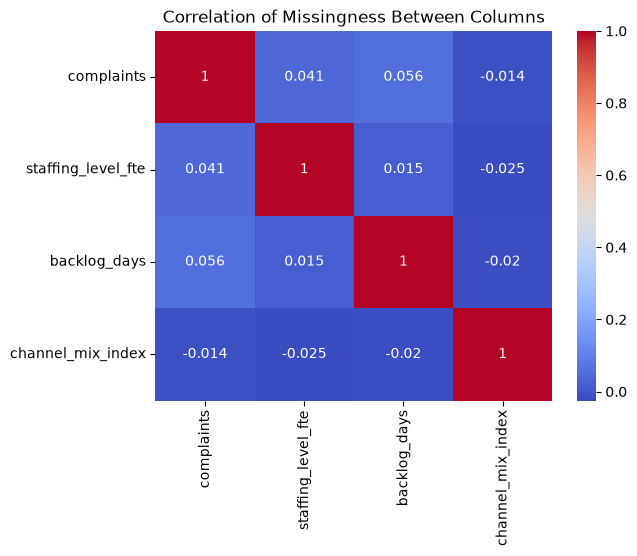

In [41]:
missing_flags = df.isna().astype(int)
missing_corr = missing_flags.corr()

# Drop rows/columns where all correlations are NaN
missing_corr = missing_corr.dropna(how='all').dropna(axis=1, how='all')

sns.heatmap(missing_corr, annot=True, cmap='coolwarm')
plt.title("Correlation of Missingness Between Columns")

doesn't appear to be any clearly related reasons between features for missing values, and none are highly correlated with the outcome. Is there a clear time that this data is missing?

Text(70.38563368055554, 0.5, 'Columns')

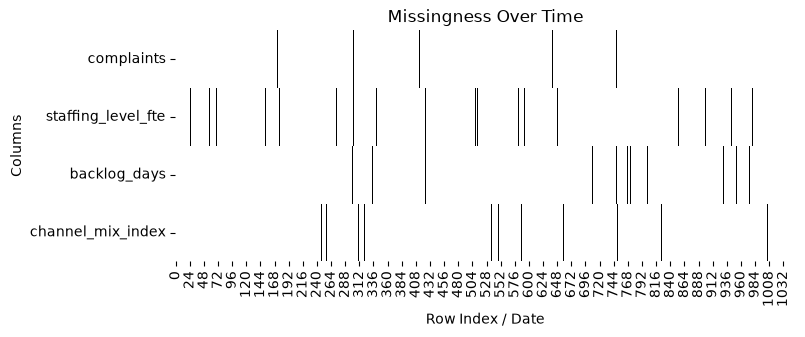

In [57]:
cols_with_missing = missing_flags.columns[missing_flags.sum() > 0]
plt.figure(figsize=(8,3))
sns.heatmap(missing_flags[cols_with_missing].T, cmap='Greys', cbar=False)
plt.title("Missingness Over Time")
plt.xlabel("Row Index / Date")
plt.ylabel("Columns")

No clear time or other variable reason for the data to be missing. I will assume here that the data is missing at random.

## Impute missing data

As the data is assumed to be missing at random, I will impute missing data. I will avoid evaluating on these points when the model is trained.

In [43]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
full_range = pd.date_range(df.index.min(), df.index.max(), freq='D')

df = df.reindex(full_range)
df.index.name = 'date'
df['new_data'] = df.isna().all(axis=1).astype(int)
df = df.reset_index()

back log days will be likely very close day to day. I will just average the backlog value the day before and day after

In [44]:
df['backlog_days'] = df['backlog_days'].interpolate(method='linear')

channel log index will be likely very close day to day. I will just average the channel log index value the day before and day after

In [45]:
df['channel_mix_index'] = df['channel_mix_index'].interpolate(method='linear')

Staffing level could be correlated to day of the week.

In [46]:
df['day_of_week'] = df['date'].dt.dayofweek  
df['day_name'] = df['date'].dt.day_name() 
corr = df['staffing_level_fte'].corr(df['day_of_week'])
print(corr)

0.19494173371850537


The correaltion for staffing level isn't that high, should average of day before/after be used?

In [47]:
df['staffing_lag1'] = df['staffing_level_fte'].shift(1)
df['staffing_lead1'] = df['staffing_level_fte'].shift(-1)
corr_lag = df['staffing_level_fte'].corr(df['staffing_lag1'])
corr_lead = df['staffing_level_fte'].corr(df['staffing_lead1'])
corr_lag, corr_lead

(np.float64(0.9193289471361638), np.float64(0.9193289471361638))

Correlation is high, impute with the average of day before and after

In [48]:
df['staffing_level_fte'] = df['staffing_level_fte'].interpolate(method='linear')

As new days were added, the other columns will have missing data as they had no values for day added. Use the average of the day before and after then drop these in evaluation

In [49]:
df['complaints'] = df['complaints'].interpolate(method='linear')
df['media_mentions'] = df['media_mentions'].interpolate(method='linear')

The missing data in is_weekend, bank_holiday_flag and centered_7d_mean can be crated as they are known

In [50]:
weekend_flag = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_weekend'] = df['is_weekend'].fillna(weekend_flag)

#bank holiday fill in - i'll use England for now but this might be changed depending on where data is from
uk_holidays = holidays.UnitedKingdom(years=range(df['date'].dt.year.min(), df['date'].dt.year.max() + 1), subdiv='England')
df['computed_bank_holiday'] = df['date'].isin(uk_holidays).astype(int)
df['bank_holiday_flag'] = df['bank_holiday_flag'].fillna(df['computed_bank_holiday'])
df = df.drop(columns=['computed_bank_holiday'])

#centred 7d mean
df['computed_centered_7d'] = df['complaints'].rolling(
    window=7, center=True
).mean()
df['centered_7d_mean'] = df['centered_7d_mean'].fillna(df['computed_centered_7d'])
df = df.drop(columns=['computed_centered_7d'])

In [51]:
## double-check missing values
df = df.drop(columns=['staffing_lag1', 'staffing_lead1'])
print(f"Rows: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Missing complaints: {df['complaints'].isna().sum()}")
print("Missing values:")
print(df.isna().sum().to_string())

Rows: 1,096
Date range: 2023-01-01 to 2025-12-31
Missing complaints: 0
Missing values:
date                   0
row_id                43
complaints             0
is_weekend             0
bank_holiday_flag      0
staffing_level_fte     0
backlog_days           0
media_mentions         0
channel_mix_index      0
centered_7d_mean       0
new_data               0
day_of_week            0
day_name               0
staffing_lag1         75
staffing_lead1        75


### Features

In [52]:
print(df.columns)

Index(['date', 'row_id', 'complaints', 'is_weekend', 'bank_holiday_flag',
       'staffing_level_fte', 'backlog_days', 'media_mentions',
       'channel_mix_index', 'centered_7d_mean', 'new_data', 'day_of_week',
       'day_name', 'staffing_lag1', 'staffing_lead1'],
      dtype='str')


Text(0, 0.5, 'Daily Complaints')

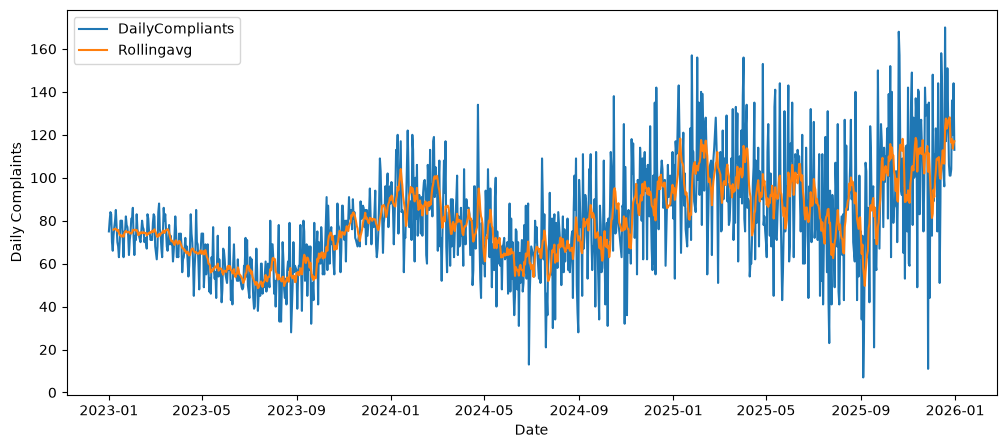

In [53]:
df[ '7day_rolling_avg' ] = df.complaints.rolling( 7).mean()
# set figure size
plt.figure( figsize = ( 12, 5))
sns.lineplot( x = 'date',
             y = 'complaints',
             data = df,
             label = 'DailyCompliants')
# plot using rolling average
sns.lineplot( x = 'date',
             y = '7day_rolling_avg',
             data = df,
             label = 'Rollingavg')
plt.xlabel( 'Date')
plt.ylabel('Daily Complaints')

Compliants seem to be increasing in number over time as well as increasing in variance. There is potentially some seasonality

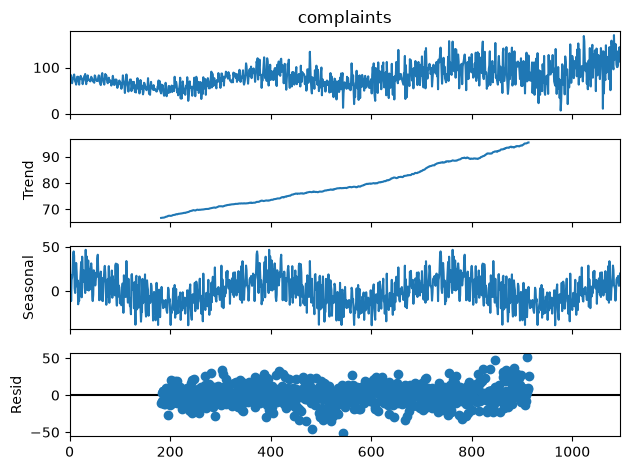

In [54]:
from statsmodels.tsa.seasonal import seasonal_decompose
#df = df.set_index('date')
result = seasonal_decompose(df['complaints'], model='additive', period=365)
result.plot()
plt.show()

There is a clear seasonsal and trend to the data. It is worth considering that the amount of data we have is quite low (only a few years) so we can't be sure this pattern is so strong

### Break down the seasonality

In [55]:
print("\n" + "=" * 70)
print("WEEKLY SEASONALITY (mean complaints by day-of-week)")
print("=" * 70)
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print(df.assign(dow=df["date"].dt.day_name())
      .groupby("dow")["complaints"].mean().reindex(dow_order).round(1))


2. WEEKLY SEASONALITY (mean complaints by day-of-week)
dow
Monday       86.1
Tuesday      85.2
Wednesday    84.5
Thursday     74.4
Friday       72.3
Saturday     76.1
Sunday       82.1
Name: complaints, dtype: float64


In [63]:
print("ANNUAL SEASONALITY (mean complaints by month)")
monthly = df.assign(ym=df["date"].dt.to_period("M")).groupby("ym")["complaints"].mean()
print(monthly.round(1).to_string())

ANNUAL SEASONALITY (mean complaints by month)
ym
2023-01     75.0
2023-02     74.6
2023-03     72.3
2023-04     65.5
2023-05     59.4
2023-06     55.9
2023-07     53.5
2023-08     53.9
2023-09     58.6
2023-10     70.4
2023-11     78.2
2023-12     83.3
2024-01     91.9
2024-02     90.6
2024-03     80.5
2024-04     77.9
2024-05     70.3
2024-06     59.6
2024-07     65.1
2024-08     67.1
2024-09     76.6
2024-10     79.3
2024-11     87.1
2024-12     92.4
2025-01     97.8
2025-02    105.9
2025-03     99.0
2025-04     94.7
2025-05     90.5
2025-06     93.2
2025-07     79.0
2025-08     82.6
2025-09     80.4
2025-10    103.1
2025-11    106.6
2025-12    113.4
Freq: M


Consistent pattern across all 3 years: trough Jun-Aug, peak Dec-Feb. Also a clear year-on-year upward drift:

In [61]:
print(f"2023 mean: {df[df.date.dt.year==2023]['complaints'].mean():.0f}")
print(f"2024 mean: {df[df.date.dt.year==2024]['complaints'].mean():.0f}")
print(f"2025 mean: {df[df.date.dt.year==2025]['complaints'].mean():.0f}")

2023 mean: 67
2024 mean: 78
2025 mean: 95


In [65]:
print("BANK HOLIDAY EFFECT")
import statsmodels.api as sm
X = pd.get_dummies(df["date"].dt.dayofweek, prefix="dow", drop_first=True).astype(float)
X["holiday"] = df["bank_holiday_flag"].astype(float)
X = sm.add_constant(X)
ols = sm.OLS(df["complaints"].astype(float), X).fit()
print(f"Holiday coefficient: {ols.params['holiday']:+.1f} complaints/day "
          f"(p={ols.pvalues['holiday']:.2f})")

BANK HOLIDAY EFFECT
Holiday coefficient: +7.5 complaints/day (p=0.15)


Not significant, and only 24 holidays in the data. Maybe ignore as adjustment in modelling?

In [67]:
print("CORRELATION WITH OPERATIONAL COVARIATES")
corr = df[["complaints", "staffing_level_fte", "backlog_days",
               "media_mentions", "channel_mix_index"]].corr()["complaints"]
print(corr.round(2).to_string())

CORRELATION WITH OPERATIONAL COVARIATES
complaints            1.00
staffing_level_fte    0.39
backlog_days          0.28
media_mentions       -0.04
channel_mix_index     0.01


staffing_level_fte and backlog_days correlate positively with complaints, but this could be reactive (more staff/backlog follows more complaints) rather than predictive, and future values of these are unknown 90 days out. In the main model probably best excluded.

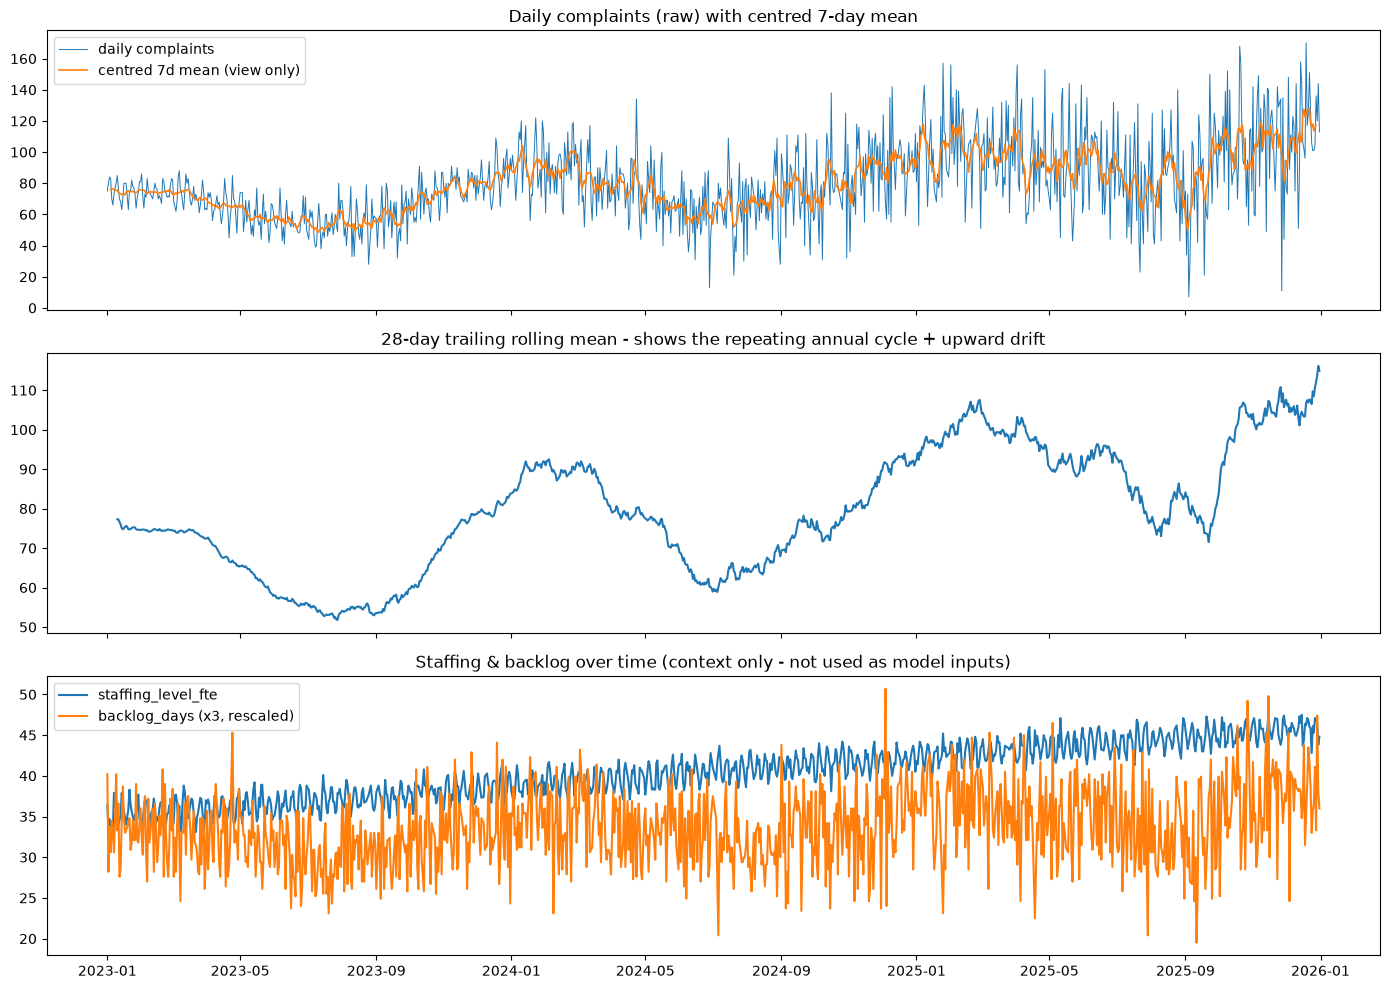

In [68]:
# ---- plot ----
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df["date"], df["complaints"], lw=0.7, color="tab:blue", label="daily complaints")
axes[0].plot(df["date"], df["complaints"].rolling(7, center=True).mean(),
                 lw=1.2, color="tab:orange", label="centred 7d mean (view only)")
axes[0].set_title("Daily complaints (raw) with centred 7-day mean")
axes[0].legend()

roll28 = df.set_index("date")["complaints"].rolling(28, min_periods=10).mean()
axes[1].plot(df["date"], roll28)
axes[1].set_title("28-day trailing rolling mean - shows the repeating annual cycle + upward drift")

axes[2].plot(df["date"], df["staffing_level_fte"], label="staffing_level_fte")
axes[2].plot(df["date"], df["backlog_days"] * 3, label="backlog_days (x3, rescaled)")
axes[2].set_title("Staffing & backlog over time (context only - not used as model inputs)")
axes[2].legend()
plt.tight_layout()